In [1]:
# Cell 1: setup
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow.pytorch
import numpy as np
from dotenv import load_dotenv
from mlflow import MlflowClient

from ecgvae.data.mitbih import ECGBeatDataset
from ecgvae.utils.config import load_config
from ecgvae.utils.device import get_device
from ecgvae.utils.mlflow_utils import setup_mlflow
from ecgvae.utils.seeding import set_seed

load_dotenv(Path("..") / ".env")  # assumes notebook lives in notebooks/, same as data.ipynb

# None -> latest version across ALL registered models (i.e. whatever the
# most recent training run registered, regardless of architecture).
# Set to a specific registered model name (e.g. "vanilla_vae") to instead
# get the latest version of just that model.
MODEL_NAME = None
CONFIG_PATH = Path("..") / "configs" / "vanilla_vae.yaml"
NUM_EXAMPLES = 5

In [2]:
# Cell 2: load model + data
config = load_config(CONFIG_PATH)
set_seed(config["training"]["seed"])
device = get_device(config)

setup_mlflow(config)

client = MlflowClient()
# filter_string=None (MODEL_NAME unset) searches across every registered
# model, not just one -- filtered to a specific name otherwise.
filter_string = f"name='{MODEL_NAME}'" if MODEL_NAME else None
versions = client.search_model_versions(filter_string)
assert versions, (
    f"No registered versions found for '{MODEL_NAME}'" if MODEL_NAME
    else "No registered model versions found at all -- has any training run registered one yet?"
)
latest_mv = max(versions, key=lambda mv: mv.creation_timestamp)
MODEL_URI = f"models:/{latest_mv.name}/{latest_mv.version}"
print(f"Loading {MODEL_URI} ({len(versions)} version(s) matched)")

model = mlflow.pytorch.load_model(MODEL_URI)
model.to(device)
model.eval()

train_ds = ECGBeatDataset(split="train", normalize=True, verbose=False)
test_ds = ECGBeatDataset(split="test", normalize=True, verbose=False)

Loading models:/fc_vanilla_vae/1 (7 version(s) matched)


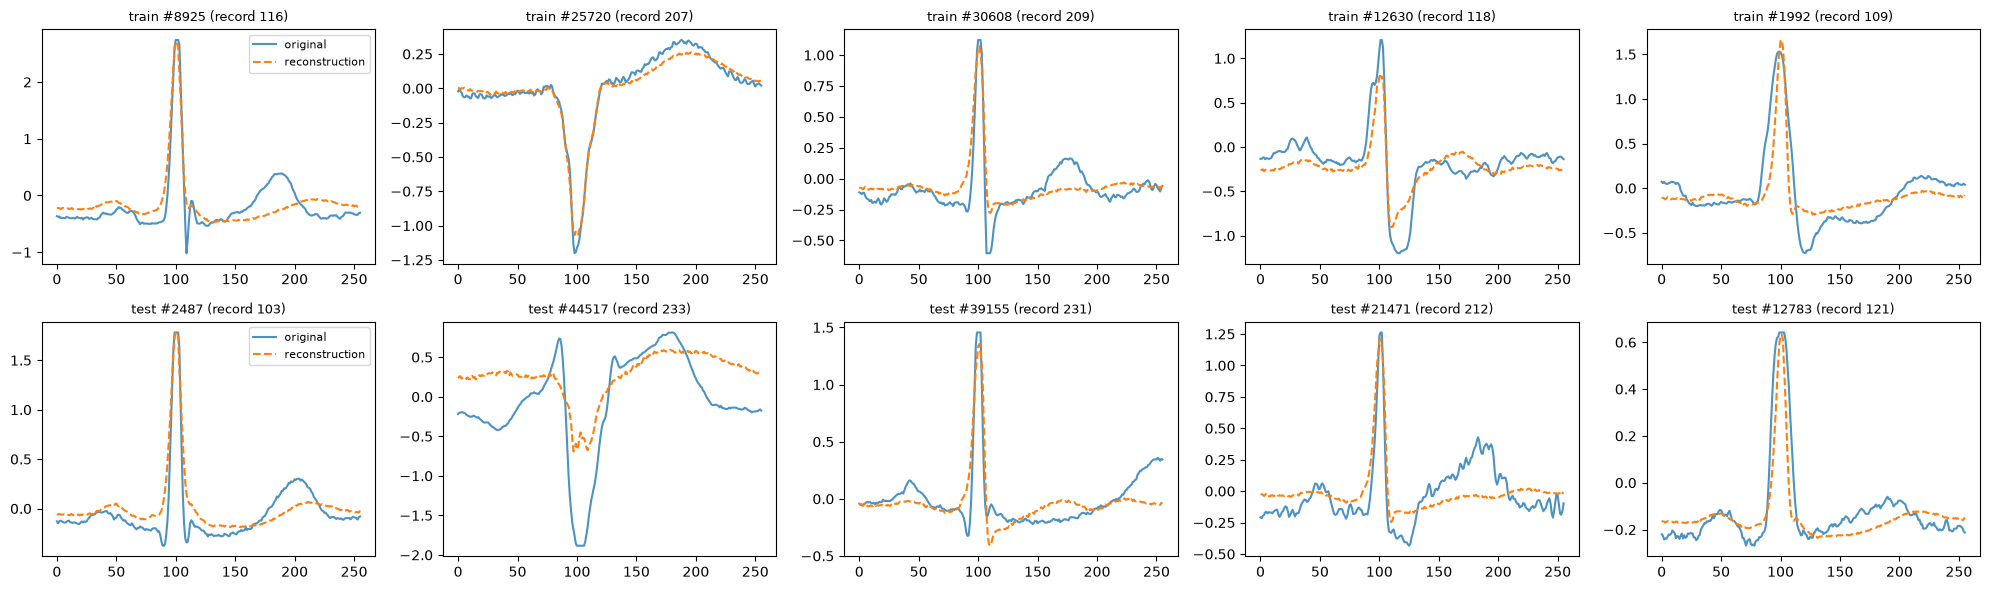

In [3]:
# Cell 3: pick random examples + reconstruct + plot
def plot_split(dataset, indices, split_name, ax_row):
    for col, idx in enumerate(indices):
        sample = dataset[idx]
        x = sample["waveform"].unsqueeze(0).to(device)
        recon = model.reconstruct(x)  # deterministic: uses mu, no sampling noise

        record_id = sample["record_id"]
        x_real = dataset.denormalize(x.squeeze(0).cpu().numpy(), record_id)
        recon_real = dataset.denormalize(recon.squeeze(0).cpu().numpy(), record_id)

        ax = ax_row[col]
        ax.plot(x_real, label="original", alpha=0.8)
        ax.plot(recon_real, label="reconstruction", linestyle="--")
        ax.set_title(f"{split_name} #{idx} (record {record_id})", fontsize=9)
        if col == 0:
            ax.legend(fontsize=8)


train_indices = np.random.choice(len(train_ds), size=NUM_EXAMPLES, replace=False)
test_indices = np.random.choice(len(test_ds), size=NUM_EXAMPLES, replace=False)

fig, axes = plt.subplots(2, NUM_EXAMPLES, figsize=(4 * NUM_EXAMPLES, 6))
plot_split(train_ds, train_indices, "train", axes[0])
plot_split(test_ds, test_indices, "test", axes[1])
plt.tight_layout()
plt.show()